# Segment-Level (classical) Analysis — store-backed

Classical Hopfield-solver segment metrics read from **`qtrk_store`** via `qtrk_view` (recomputed VIEW; fixed gamma-aware absolute threshold, never baked pkl metrics). Covers the multiplicity, scattering, resolution, hit-inefficiency and cone sweeps.

**Omitted vs the old notebook:** the spectral diagnostics (condition number kappa) and the tracker A/B (connected-components vs layered) — those need the matrix A and `get_tracks`, which the store does not persist. Re-derive separately if needed.

In [1]:
# Setup
import sys, pathlib
sys.path.insert(0, '/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/_shared')
sys.path.insert(0, '/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Verify_new_results')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import qtrk_view as V

OUT = pathlib.Path('outputs/segment_analysis/store_backed'); OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.size':12,'axes.grid':True,'grid.alpha':0.3,'lines.markersize':6,'lines.linewidth':1.8})
def _save(fig,stem):
    fig.savefig(OUT/f'{stem}.pdf', bbox_inches='tight'); fig.savefig(OUT/f'{stem}.png', dpi=150, bbox_inches='tight'); print('saved', stem)

# all CLASSICAL solves across studies (the segment-level characterisation set).
# STANDARD VALIDITY GATE (audit 2026-07-05): sweep over VALID rows only —
# max|x| <= 50; lambda_min->0 explosions are solver-regime artefacts and
# ungated per-cell means mistake them for physics. load_view() attaches `valid`.
view = V.load_view()
C = view[(view.solver=='classical') & view.valid].copy()
n_all = int((view.solver=='classical').sum())
print(f'classical solves: {len(C)} valid of {n_all} '
      f'({n_all-len(C)} dropped by the max|x|<=50 gate) | studies:', sorted(C.study.unique()))
print('axes: T', sorted(C.n_trk.unique()), '| sigma_scatt', sorted(C.sigma_scatt.unique()),
      '| sigma_res', sorted(C.sigma_res.unique()), '| phi_max', sorted(C.phi_max.unique()),
      '| hit_ineff', sorted(C.hit_ineff.unique()))
def sweep(df, xcol, fixed):
    q=df.copy()
    for k,v in fixed.items(): q=q[np.isclose(q[k], v)] if q[k].dtype.kind=='f' else q[q[k]==v]
    g=q.groupby(xcol)
    out=pd.DataFrame({xcol:sorted(q[xcol].unique())}).set_index(xcol)
    for met in ['segment_efficiency','segment_false_rate','segment_purity']:
        out[met+'_m']=g[met].mean(); out[met+'_s']=g[met].apply(lambda x: x.std(ddof=1)/np.sqrt(len(x)) if len(x)>1 else 0.0)
    out['n']=g.size()
    return out.reset_index()
def plot_sweep(df, xcol, fixed, title, stem, logx=True, logy_far=True):
    s=sweep(df,xcol,fixed)
    fig,ax=plt.subplots(1,2,figsize=(13,4.5))
    if len(s):
        ax[0].errorbar(s[xcol],s['segment_efficiency_m'],yerr=s['segment_efficiency_s'],fmt='o-',capsize=4,color='#1b7837',label='efficiency')
        ax[0].errorbar(s[xcol],s['segment_purity_m'],yerr=s['segment_purity_s'],fmt='s--',capsize=4,color='#2166ac',label='purity')
        ax[1].errorbar(s[xcol],s['segment_false_rate_m'],yerr=s['segment_false_rate_s'],fmt='o-',capsize=4,color='#c51b7d')
    ax[0].set_ylim(0,1.05); ax[0].set_ylabel('efficiency / purity'); ax[0].legend(); ax[0].set_title(title+' — eff/purity')
    ax[1].set_ylabel('false rate = N_false_act/N_active'); ax[1].set_title(title+' — false rate')
    if logy_far: ax[1].set_yscale('log')
    for a in ax:
        a.set_xlabel(xcol)
        if logx: a.set_xscale('log')
    fig.tight_layout(); _save(fig,stem); plt.show()
    return s

classical solves: 12747 valid of 14683 (1936 dropped by the max|x|<=50 gate) | studies: ['ERF', 'Epsilon_study_2', 'Larger_Scatter', 'Larger_Scatter_Density', 'Noisy_Density', 'Noisy_Ladder', 'QSVT_codesign', 'QSVT_robustness', 'Verify_new_results']
axes: T [np.int64(10), np.int64(20), np.int64(30), np.int64(50), np.int64(75), np.int64(100), np.int64(150), np.int64(200), np.int64(300), np.int64(400), np.int64(550), np.int64(700), np.int64(1000)] | sigma_scatt [np.float64(0.0001), np.float64(0.0002), np.float64(0.0003), np.float64(0.0004), np.float64(0.0005), np.float64(0.0006), np.float64(0.0007), np.float64(0.0008), np.float64(0.001)] | sigma_res [np.float64(0.0), np.float64(0.0025), np.float64(0.005), np.float64(0.0075), np.float64(0.01), np.float64(0.02), np.float64(0.05)] | phi_max [np.float64(0.01), np.float64(0.02), np.float64(0.05), np.float64(0.1), np.float64(0.2)] | hit_ineff [np.float64(0.0), np.float64(0.005), np.float64(0.01), np.float64(0.02), np.float64(0.03), np.float64(

saved fig1_vs_T


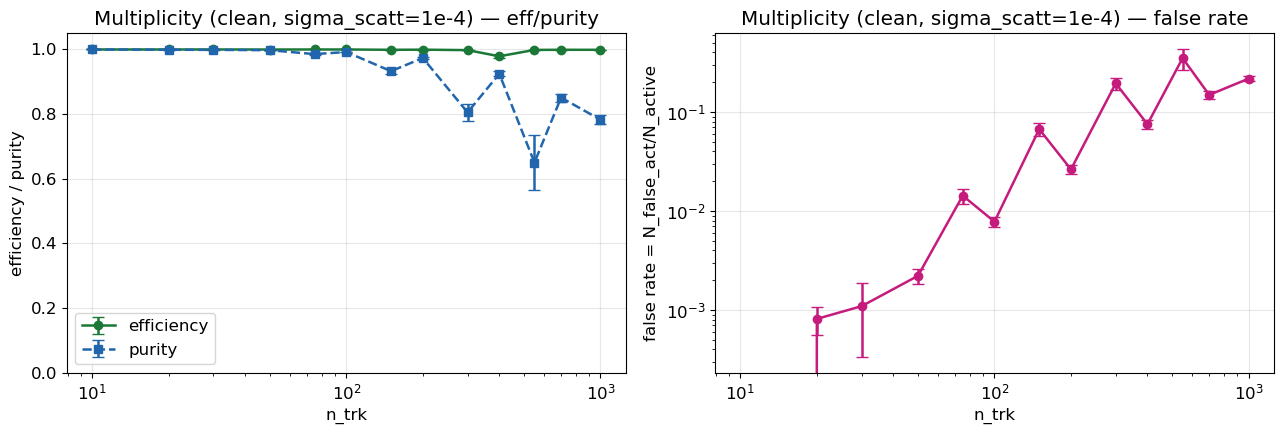

,n_trk,segment_efficiency_m,segment_efficiency_s,segment_false_rate_m,segment_false_rate_s,segment_purity_m,segment_purity_s,n
0,10,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,300
1,20,1.000000,0.000000,0.000813,0.000253,0.999187,0.000253,300
2,30,1.000000,0.000000,0.001093,0.000759,0.998907,0.000759,30
3,50,0.999900,0.000040,0.002212,0.000399,0.997788,0.000399,300
4,75,1.000000,0.000000,0.014279,0.002432,0.985721,0.002432,30
5,100,1.000000,0.000000,0.007800,0.000933,0.992200,0.000933,298
6,150,0.999048,0.000661,0.067068,0.009532,0.932932,0.009532,28
7,200,0.999449,0.000153,0.026324,0.002939,0.973676,0.002939,295
8,300,0.998025,0.000781,0.194516,0.027332,0.805484,0.027332,27
9,400,0.979011,0.004734,0.075278,0.008198,0.924722,0.008198,318


In [2]:
# Fig 1 — segment metrics vs track multiplicity (low-noise baseline)
plot_sweep(C, 'n_trk', dict(sigma_res=0.0, sigma_scatt=1e-4, phi_max=0.2, hit_ineff=0.0),
           'Multiplicity (clean, sigma_scatt=1e-4)', 'fig1_vs_T')

saved fig2_vs_sigma_scatt


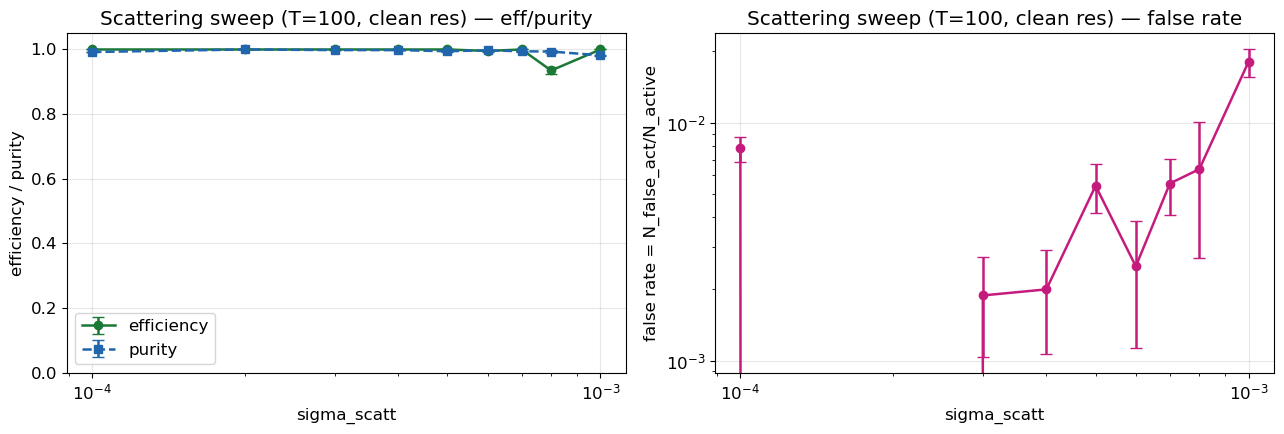

,sigma_scatt,segment_efficiency_m,segment_efficiency_s,segment_false_rate_m,segment_false_rate_s,segment_purity_m,segment_purity_s,n
0,0.0001,1.0000,0.000000,0.007800,0.000933,0.992200,0.000933,298
1,0.0002,1.0000,0.000000,0.000000,0.000000,1.000000,0.000000,5
2,0.0003,1.0000,0.000000,0.001879,0.000846,0.998121,0.000846,25
3,0.0004,1.0000,0.000000,0.001993,0.000931,0.998007,0.000931,5
4,0.0005,1.0000,0.000000,0.005431,0.001268,0.994569,0.001268,25
5,0.0006,0.9955,0.003905,0.002490,0.001362,0.997510,0.001362,5
6,0.0007,1.0000,0.000000,0.005553,0.001456,0.994447,0.001456,20
7,0.0008,0.9350,0.011456,0.006382,0.003679,0.993618,0.003679,5
8,0.0010,1.0000,0.000000,0.018051,0.002413,0.981949,0.002413,20


In [3]:
# Fig 2 — scattering sweep (vs sigma_scatt), per fixed T
plot_sweep(C, 'sigma_scatt', dict(sigma_res=0.0, phi_max=0.2, hit_ineff=0.0, n_trk=100),
           'Scattering sweep (T=100, clean res)', 'fig2_vs_sigma_scatt', logx=True)

saved fig3_vs_sigma_res


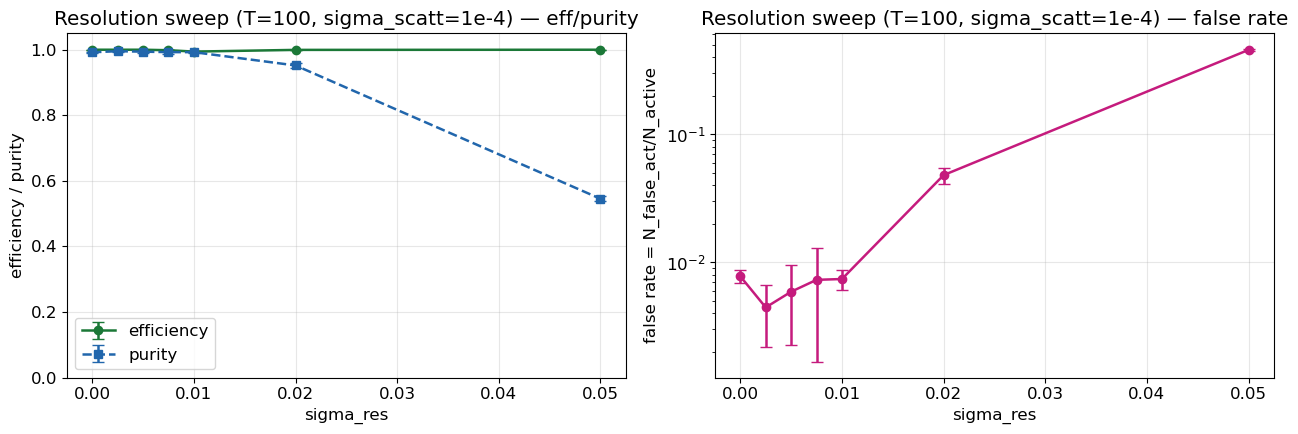

,sigma_res,segment_efficiency_m,segment_efficiency_s,segment_false_rate_m,segment_false_rate_s,segment_purity_m,segment_purity_s,n
0,0.0000,1.0000,0.000000,0.007800,0.000933,0.992200,0.000933,298
1,0.0025,1.0000,0.000000,0.004459,0.002264,0.995541,0.002264,5
2,0.0050,1.0000,0.000000,0.005911,0.003620,0.994089,0.003620,5
3,0.0075,0.9985,0.000612,0.007318,0.005640,0.992682,0.005640,5
4,0.0100,0.9943,0.002608,0.007426,0.001326,0.992574,0.001326,25
5,0.0200,0.9995,0.000500,0.047978,0.006726,0.952022,0.006726,20
6,0.0500,1.0000,0.000000,0.454672,0.007293,0.545328,0.007293,20


In [4]:
# Fig 3 — resolution sweep (vs sigma_res), per fixed T
plot_sweep(C, 'sigma_res', dict(sigma_scatt=1e-4, phi_max=0.2, hit_ineff=0.0, n_trk=100),
           'Resolution sweep (T=100, sigma_scatt=1e-4)', 'fig3_vs_sigma_res', logx=False)

saved fig4_vs_hit_ineff


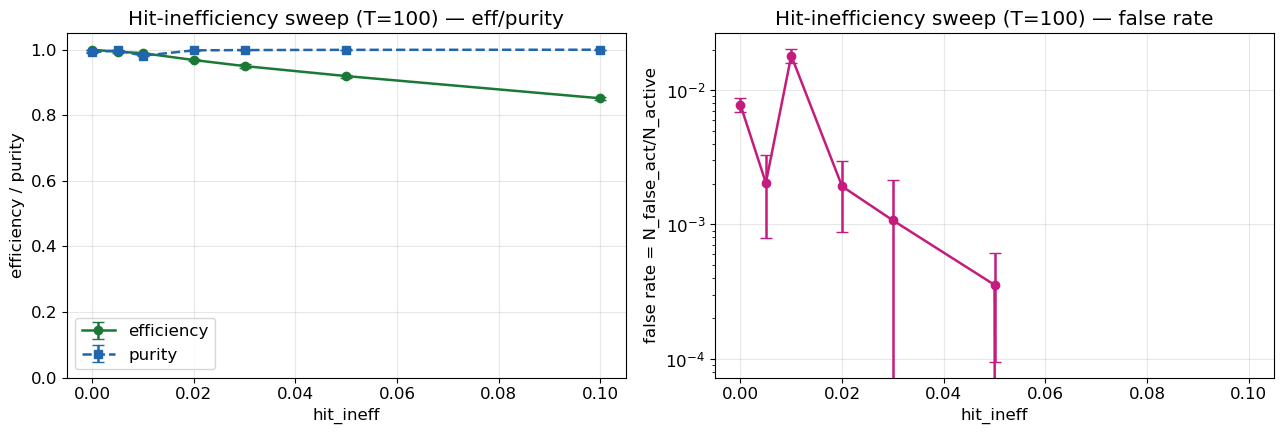

,hit_ineff,segment_efficiency_m,segment_efficiency_s,segment_false_rate_m,segment_false_rate_s,segment_purity_m,segment_purity_s,n
0,0.000,1.000000,0.000000,0.007800,0.000933,0.992200,0.000933,298
1,0.005,0.993924,0.002496,0.002038,0.001248,0.997962,0.001248,5
2,0.010,0.989463,0.000824,0.018126,0.002212,0.981874,0.002212,120
3,0.020,0.968530,0.002961,0.001924,0.001046,0.998076,0.001046,25
4,0.030,0.950076,0.006943,0.001072,0.001072,0.998928,0.001072,5
5,0.050,0.919586,0.004813,0.000354,0.000260,0.999646,0.000260,25
6,0.100,0.851838,0.004961,0.000000,0.000000,1.000000,0.000000,20


In [5]:
# Fig 4 — hit-inefficiency sweep (vs hit_ineff / p_drop)
plot_sweep(C, 'hit_ineff', dict(sigma_res=0.0, sigma_scatt=1e-4, phi_max=0.2, n_trk=100),
           'Hit-inefficiency sweep (T=100)', 'fig4_vs_hit_ineff', logx=False)

saved fig5_vs_phi_max


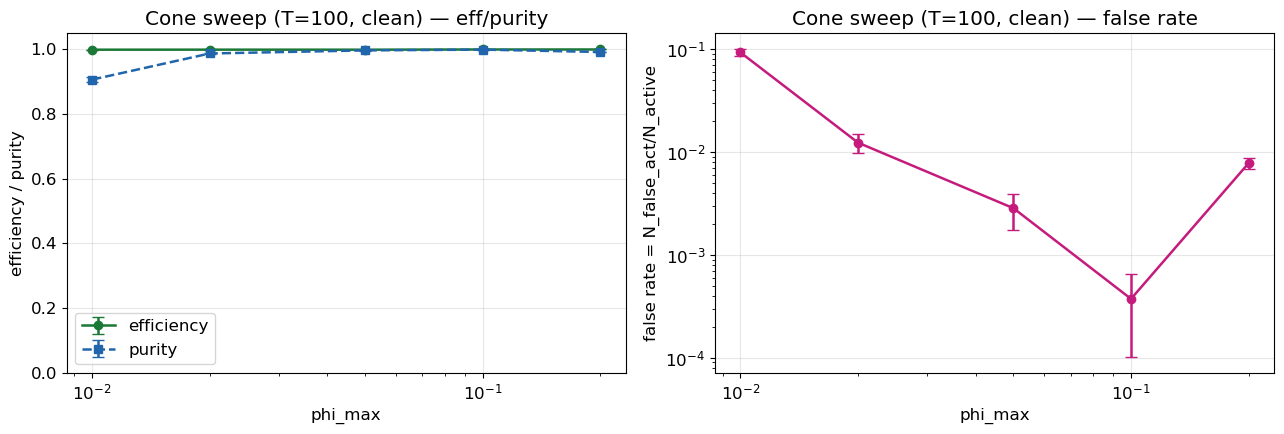

,phi_max,segment_efficiency_m,segment_efficiency_s,segment_false_rate_m,segment_false_rate_s,segment_purity_m,segment_purity_s,n
0,0.01,0.999375,0.000509,0.093173,0.008036,0.906827,0.008036,20
1,0.02,0.999500,0.000500,0.012348,0.002482,0.987652,0.002482,20
2,0.05,0.999375,0.000509,0.002845,0.001107,0.997155,0.001107,20
3,0.10,1.000000,0.000000,0.000373,0.000272,0.999627,0.000272,20
4,0.20,1.000000,0.000000,0.007800,0.000933,0.992200,0.000933,298


In [6]:
# Fig 5 — angular cone sweep (vs phi_max)
plot_sweep(C, 'phi_max', dict(sigma_res=0.0, sigma_scatt=1e-4, hit_ineff=0.0, n_trk=100),
           'Cone sweep (T=100, clean)', 'fig5_vs_phi_max', logx=True)

## Notes / provenance
- Source: `/data/bfys/gscriven/qtrk_store` via `qtrk_view`/`qtrk_pipeline.load_metrics` (classical solves, all studies). Metrics recomputed (gamma-aware absolute threshold; false rate = N_false_active/N_active).
- The fixed slices above pick a representative point on the other axes; adjust the `fixed=` dicts to slice differently. Coverage grows as Condor drains and `build_metrics.py` is re-run.
- **Not reproducible from the store:** condition-number / eigenspectrum (needs the matrix A, regenerate via `qtrk_pipeline.build_hamiltonian`) and tracker A/B (needs `get_tracks` on the solution).